In [7]:
# STEP 1: INITIALIZE ENVIRONMENT & LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Step 1 Complete: All libraries imported successfully!")

Step 1 Complete: All libraries imported successfully!


In [2]:
# STEP 2: DATA GENERATION & STRUCTURAL SETUP

np.random.seed(42)
n_samples = 1000

# Generating core features
sqft = np.random.normal(2200, 600, n_samples).astype(int)
bedrooms = np.random.choice([2, 3, 4, 5], size=n_samples, p=[0.2, 0.5, 0.2, 0.1])
bathrooms = bedrooms - np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3])
age = np.random.randint(1, 40, n_samples)
neighborhood = np.random.choice(['Suburbs', 'Downtown', 'Rural'], size=n_samples, p=[0.5, 0.3, 0.2])

# Implementing the continuous pricing formula (base price + structural factors)
price = (sqft * 160) + (bedrooms * 22000) + (bathrooms * 14000) - (age * 950) + np.random.normal(0, 15000, n_samples)

# Adjusting values based on geographic categorical conditions
price = np.where(neighborhood == 'Downtown', price + 45000, price)
price = np.where(neighborhood == 'Rural', price - 25000, price)

# Assemble into a clean Pandas DataFrame
df = pd.DataFrame({
    'SqFt': sqft,
    'Bedrooms': bedrooms,
    'Bathrooms': bathrooms,
    'Age': age,
    'Neighborhood': neighborhood,
    'Price': price
})

print(f"Step 2 Complete: Clean dataset prepared with shape: {df.shape}")
df.head()

Step 2 Complete: Clean dataset prepared with shape: (1000, 6)


,SqFt,Bedrooms,Bathrooms,Age,Neighborhood,Price
0,2498,2,2,18,Downtown,520130.654918
1,2117,2,2,2,Downtown,429326.832423
2,2588,3,3,13,Suburbs,513259.769422
3,3113,4,4,15,Downtown,664728.453596
4,2059,2,1,20,Suburbs,370302.348865


In [3]:
# STEP 3: FEATURE ENGINEERING & ENCODING

df['Avg_Room_Size'] = df['SqFt'] / (df['Bedrooms'] + df['Bathrooms'])

df_encoded = pd.get_dummies(df, columns=['Neighborhood'], drop_first=True)

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'bool':
        df_encoded[col] = df_encoded[col].astype(int)

print("Step 3 Complete: Transformations processed successfully.")
df_encoded.head()

Step 3 Complete: Transformations processed successfully.


,SqFt,Bedrooms,Bathrooms,Age,Price,Avg_Room_Size,Neighborhood_Rural,Neighborhood_Suburbs
0,2498,2,2,18,520130.654918,624.500000,0,0
1,2117,2,2,2,429326.832423,529.250000,0,0
2,2588,3,3,13,513259.769422,431.333333,0,1
3,3113,4,4,15,664728.453596,389.125000,0,0
4,2059,2,1,20,370302.348865,686.333333,0,1


In [4]:
# STEP 4: DATA PARTITIONING & TRAINING

X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)

print("Step 4 Complete: Linear Regression weights computed and model fitting finalized.")

Step 4 Complete: Linear Regression weights computed and model fitting finalized.


============== PROJECT ACCURACY REPORT ==============
Mean Absolute Error (MAE):       $12,480.53
Root Mean Squared Error (RMSE):   $15,707.44
Coefficient of Determination(R2): 0.9787 (97.87%)


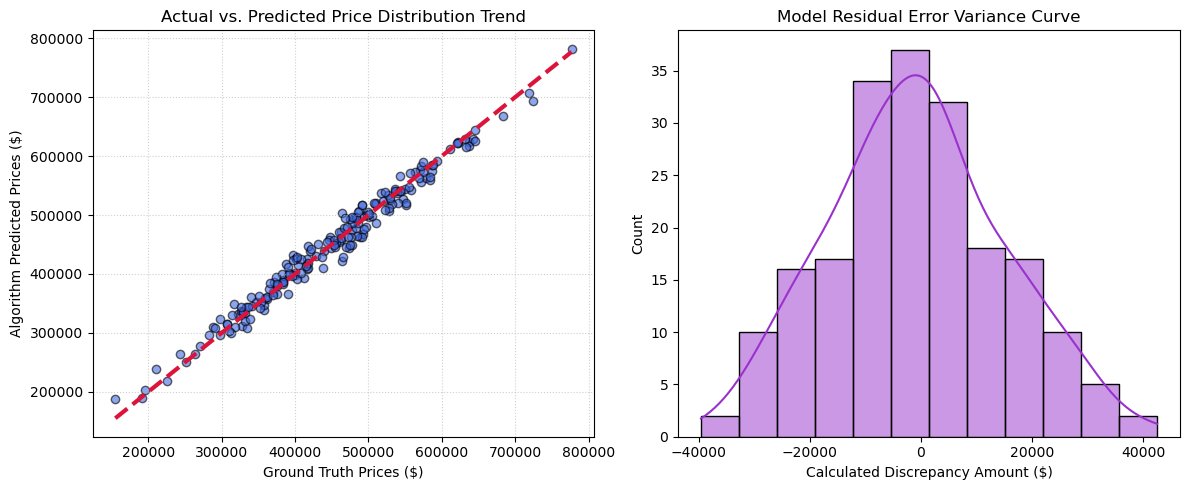

In [5]:
# STEP 5: EVALUATION METRICS & DIAGNOSTICS

y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("============== PROJECT ACCURACY REPORT ==============")
print(f"Mean Absolute Error (MAE):       ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE):   ${rmse:,.2f}")
print(f"Coefficient of Determination(R2): {r2:.4f} ({r2*100:.2f}%)")
print("=====================================================")


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, color='royalblue', edgecolor='k', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='crimson', linestyle='--', lw=3)
plt.xlabel('Ground Truth Prices ($)')
plt.ylabel('Algorithm Predicted Prices ($)')
plt.title('Actual vs. Predicted Price Distribution Trend')
plt.grid(True, linestyle=':', alpha=0.6)


plt.subplot(1, 2, 2)
sns.histplot(y_test - y_pred, kde=True, color='darkorchid')
plt.title('Model Residual Error Variance Curve')
plt.xlabel('Calculated Discrepancy Amount ($)')

plt.tight_layout()
plt.show()

In [6]:
# STEP 6: INTERACTIVE LIVE INFERENCE TEST

def run_live_prediction(sqft_val, bedroom_count, bathroom_count, house_age, sector_name):
    
    is_downtown = 1 if sector_name.lower() == 'downtown' else 0
    is_suburbs = 1 if sector_name.lower() == 'suburbs' else 0
    
    avg_room = sqft_val / (bedroom_count + bathroom_count)
    
    
    structured_vector = pd.DataFrame(
        [[sqft_val, bedroom_count, bathroom_count, house_age, avg_room, is_suburbs, is_downtown]], 
        columns=X.columns
    )
    
    val_estimate = model.predict(structured_vector)
    return val_estimate[0]

# --- SAMPLE RUN PROOF ---
sample_sqft = 2400
sample_beds = 4
sample_baths = 2
sample_age = 6
sample_zone = 'Downtown'

output_price = run_live_prediction(sample_sqft, sample_beds, sample_baths, sample_age, sample_zone)

print("Step 6 Complete: Interactive validation functioning perfectly!")
print(f"Estimated Valuation for a {sample_age}-yr old {sample_beds} BHK ({sample_sqft} SqFt) in {sample_zone}: ${output_price:,.2f}")

Step 6 Complete: Interactive validation functioning perfectly!
Estimated Valuation for a 6-yr old 4 BHK (2400 SqFt) in Downtown: $495,509.34
